In [1]:
from jiwer import wer
from whisper.normalizers import EnglishTextNormalizer
import numpy as np
import matplotlib.pyplot as plt
from g2p_en import G2p
import re
import Levenshtein

In [ ]:
"""10 individuals listened to randomly sampled 35 sentences in the test set and rated them on a scale of 1-to-5 for intelligibility.
In all, we have 350 ratings."""

In [2]:
rater1 = {"1.wav":4,"2.wav":4,"3.wav":3,"4.wav":4,"5.wav":3,"6.wav":4,"7.wav":5,"8.wav":3,"9.wav":3,"10.wav":4,"11.wav":4,"12.wav":4,"13.wav":3,"14.wav":3,"15.wav":4,"16.wav":4,"17.wav":4,"18.wav":4,"19.wav":3,"20.wav":4,"21.wav":3,"22.wav":3,"23.wav":4,"24.wav":5,"25.wav":3,"26.wav":3,"27.wav":3,"28.wav":3,"29.wav":4,"30.wav":4,"31.wav":3,"32.wav":5,"33.wav":4,"34.wav":5,"35.wav":4}
rater2 = {"1.wav":5,"2.wav":4,"3.wav":4,"4.wav":4,"5.wav":4,"6.wav":4,"7.wav":5,"8.wav":4,"9.wav":5,"10.wav":5,"11.wav":5,"12.wav":5,"13.wav":3,"14.wav":4,"15.wav":4,"16.wav":4,"17.wav":3,"18.wav":5,"19.wav":5,"20.wav":5,"21.wav":4,"22.wav":4,"23.wav":5,"24.wav":3,"25.wav":4,"26.wav":4,"27.wav":5,"28.wav":3,"29.wav":4,"30.wav":3,"31.wav":5,"32.wav":4,"33.wav":5,"34.wav":4,"35.wav":4}
rater3 = {"1.wav":5,"2.wav":3,"3.wav":4,"4.wav":4,"5.wav":2,"6.wav":5,"7.wav":4,"8.wav":4,"9.wav":4,"10.wav":2,"11.wav":4,"12.wav":4,"13.wav":5,"14.wav":3,"15.wav":4,"16.wav":3,"17.wav":5,"18.wav":3,"19.wav":4,"20.wav":3,"21.wav":4,"22.wav":2,"23.wav":4,"24.wav":5,"25.wav":3,"26.wav":3,"27.wav":2,"28.wav":3,"29.wav":4,"30.wav":4,"31.wav":4,"32.wav":4,"33.wav":3,"34.wav":3,"35.wav":4}
rater4 = {"1.wav":4,"2.wav":4,"3.wav":3,"4.wav":4,"5.wav":2,"6.wav":3,"7.wav":4,"8.wav":3,"9.wav":3,"10.wav":4,"11.wav":3,"12.wav":3,"13.wav":3,"14.wav":4,"15.wav":2,"16.wav":3,"17.wav":2,"18.wav":2,"19.wav":4,"20.wav":3,"21.wav":3,"22.wav":4,"23.wav":4,"24.wav":3,"25.wav":4,"26.wav":3,"27.wav":3,"28.wav":4,"29.wav":3,"30.wav":4,"31.wav":4,"32.wav":4,"33.wav":4,"34.wav":4,"35.wav":4}
rater5 = {"1.wav":4,"2.wav":3,"3.wav":3,"4.wav":3,"5.wav":4,"6.wav":4,"7.wav":5,"8.wav":3,"9.wav":5,"10.wav":5,"11.wav":4,"12.wav":5,"13.wav":4,"14.wav":4,"15.wav":3,"16.wav":4,"17.wav":4,"18.wav":4,"19.wav":5,"20.wav":5,"21.wav":3,"22.wav":4,"23.wav":3,"24.wav":5,"25.wav":5,"26.wav":4,"27.wav":4,"28.wav":3,"29.wav":5,"30.wav":3,"31.wav":3,"32.wav":3,"33.wav":5,"34.wav":4,"35.wav":4}
rater6 = {"1.wav":4,"2.wav":4,"3.wav":5,"4.wav":5,"5.wav":5,"6.wav":4,"7.wav":4,"8.wav":4,"9.wav":3,"10.wav":4,"11.wav":4,"12.wav":5,"13.wav":4,"14.wav":5,"15.wav":4,"16.wav":4,"17.wav":5,"18.wav":4,"19.wav":4,"20.wav":5,"21.wav":5,"22.wav":5,"23.wav":4,"24.wav":4,"25.wav":5,"26.wav":4,"27.wav":4,"28.wav":5,"29.wav":5,"30.wav":4,"31.wav":4,"32.wav":5,"33.wav":4,"34.wav":3,"35.wav":4}
rater7 = {"1.wav":4,"2.wav":4,"3.wav":5,"4.wav":2,"5.wav":2,"6.wav":4,"7.wav":5,"8.wav":5,"9.wav":5,"10.wav":5,"11.wav":4,"12.wav":4,"13.wav":4,"14.wav":1,"15.wav":3,"16.wav":5,"17.wav":3,"18.wav":2,"19.wav":5,"20.wav":5,"21.wav":5,"22.wav":3,"23.wav":5,"24.wav":5,"25.wav":5,"26.wav":5,"27.wav":4,"28.wav":5,"29.wav":5,"30.wav":4,"31.wav":4,"32.wav":4,"33.wav":4,"34.wav":5,"35.wav":4}
rater8 = {"1.wav":5,"2.wav":3,"3.wav":4,"4.wav":4,"5.wav":2,"6.wav":5,"7.wav":4,"8.wav":4,"9.wav":4,"10.wav":2,"11.wav":4,"12.wav":4,"13.wav":5,"14.wav":3,"15.wav":4,"16.wav":3,"17.wav":5,"18.wav":3,"19.wav":4,"20.wav":3,"21.wav":4,"22.wav":2,"23.wav":4,"24.wav":5,"25.wav":3,"26.wav":3,"27.wav":2,"28.wav":3,"29.wav":4,"30.wav":4,"31.wav":4,"32.wav":4,"33.wav":3,"34.wav":3,"35.wav":4}
rater9 = {"1.wav":4,"2.wav":4,"3.wav":4,"4.wav":3,"5.wav":3,"6.wav":4,"7.wav":3,"8.wav":4,"9.wav":4,"10.wav":4,"11.wav":4,"12.wav":4,"13.wav":4,"14.wav":4,"15.wav":4,"16.wav":3,"17.wav":4,"18.wav":4,"19.wav":3,"20.wav":4,"21.wav":3,"22.wav":3,"23.wav":3,"24.wav":4,"25.wav":2,"26.wav":4,"27.wav":3,"28.wav":4,"29.wav":4,"30.wav":4,"31.wav":4,"32.wav":4,"33.wav":4,"34.wav":4,"35.wav":4}
rater10 = {"1.wav":4,"2.wav":3,"3.wav":3,"4.wav":4,"5.wav":3,"6.wav":4,"7.wav":5,"8.wav":2,"9.wav":2,"10.wav":4,"11.wav":3,"12.wav":3,"13.wav":4,"14.wav":4,"15.wav":3,"16.wav":3,"17.wav":4,"18.wav":4,"19.wav":3,"20.wav":2,"21.wav":3,"22.wav":2,"23.wav":4,"24.wav":4,"25.wav":2,"26.wav":3,"27.wav":4,"28.wav":2,"29.wav":2,"30.wav":3,"31.wav":4,"32.wav":3,"33.wav":4,"34.wav":4,"35.wav":3}

In [9]:
ratings = []
for i in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    which = "rater" + str(i)
    score = globals()[which].values()
    s = np.sum(list(score))/35
    ratings.append(list(score))

In [10]:
print(ratings)

[[4, 4, 3, 4, 3, 4, 5, 3, 3, 4, 4, 4, 3, 3, 4, 4, 4, 4, 3, 4, 3, 3, 4, 5, 3, 3, 3, 3, 4, 4, 3, 5, 4, 5, 4], [5, 4, 4, 4, 4, 4, 5, 4, 5, 5, 5, 5, 3, 4, 4, 4, 3, 5, 5, 5, 4, 4, 5, 3, 4, 4, 5, 3, 4, 3, 5, 4, 5, 4, 4], [5, 3, 4, 4, 2, 5, 4, 4, 4, 2, 4, 4, 5, 3, 4, 3, 5, 3, 4, 3, 4, 2, 4, 5, 3, 3, 2, 3, 4, 4, 4, 4, 3, 3, 4], [4, 4, 3, 4, 2, 3, 4, 3, 3, 4, 3, 3, 3, 4, 2, 3, 2, 2, 4, 3, 3, 4, 4, 3, 4, 3, 3, 4, 3, 4, 4, 4, 4, 4, 4], [4, 3, 3, 3, 4, 4, 5, 3, 5, 5, 4, 5, 4, 4, 3, 4, 4, 4, 5, 5, 3, 4, 3, 5, 5, 4, 4, 3, 5, 3, 3, 3, 5, 4, 4], [4, 4, 5, 5, 5, 4, 4, 4, 3, 4, 4, 5, 4, 5, 4, 4, 5, 4, 4, 5, 5, 5, 4, 4, 5, 4, 4, 5, 5, 4, 4, 5, 4, 3, 4], [4, 4, 5, 2, 2, 4, 5, 5, 5, 5, 4, 4, 4, 1, 3, 5, 3, 2, 5, 5, 5, 3, 5, 5, 5, 5, 4, 5, 5, 4, 4, 4, 4, 5, 4], [5, 3, 4, 4, 2, 5, 4, 4, 4, 2, 4, 4, 5, 3, 4, 3, 5, 3, 4, 3, 4, 2, 4, 5, 3, 3, 2, 3, 4, 4, 4, 4, 3, 3, 4], [4, 4, 4, 3, 3, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 3, 4, 3, 3, 3, 4, 2, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4], [4, 3, 3, 4, 3, 4, 5, 2, 2, 4, 3, 3,

In [5]:
print(np.mean(ratings))

3.791428571428571


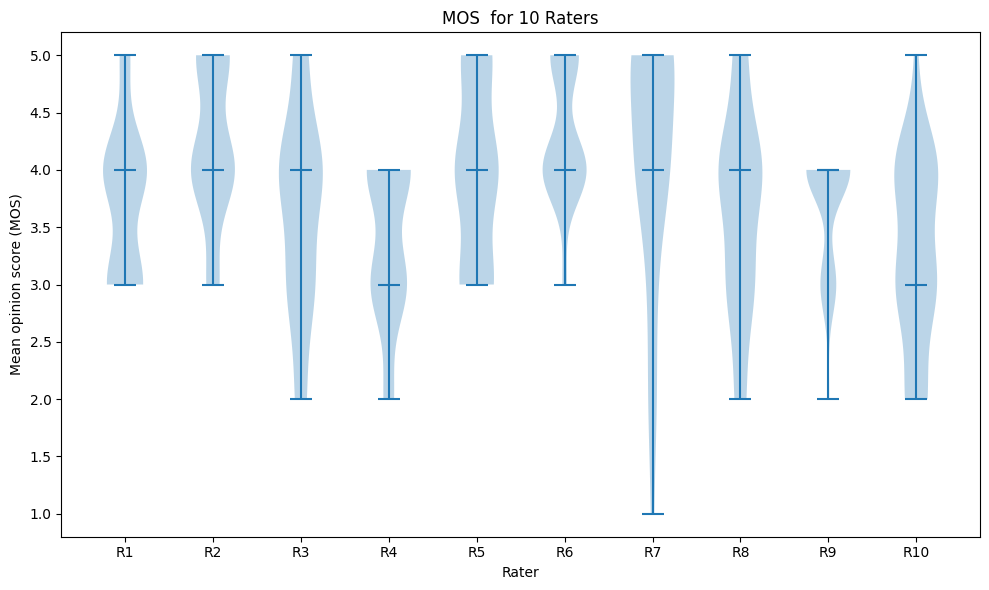

In [ ]:
fig, ax = plt.subplots(figsize = (10, 6))

parts = ax.violinplot(
    ratings,
    positions = range(1, len(ratings) + 1),
    showmeans = False,
    showmedians = True,
    showextrema = True
)

ax.set_xlabel("Rater")
ax.set_ylabel("Mean opinion score (MOS)")
ax.set_title("MOS  on a scale of 1-to-5")
ax.set_xticks(range(1, len(ratings) + 1))
ax.set_xticklabels([f"R{i}" for i in range(1, len(ratings) + 1)])

plt.tight_layout()
plt.show()